# AI in Pathology: From Tissue to Phenotype
In this notebook, we will explore how pathology foundation model can be used to encode H&E images into useful feature embeddings.

In [ ]:
# Suggest to create virtual environment before installing dependencies
# !pip install -r requirements.txt

In [2]:
from pathlib import Path
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import seaborn as sns

## Dataset exploration
- This is an example colorectal cancer (CRC) dataset (source: [NCT-CRC](https://zenodo.org/records/1214456))

The dataset contains 4 different classes: TUM (tumor), ADI (adipose), LYM (lymphocytes) and STR (stroma).

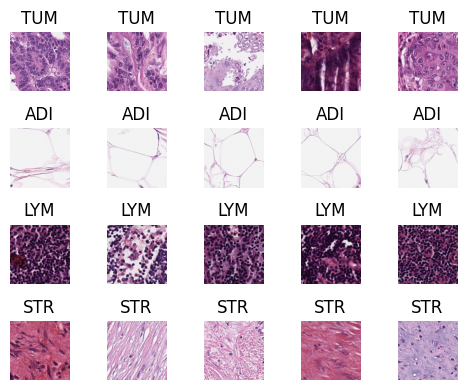

In [ ]:
# Path to your dataset
dataset_path = Path("NCT_Images/train")

# Get all class folders
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# Number of samples per class
n_samples = 5

# Plot samples images for each class
fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples*1, len(classes)*1))

if len(classes) == 1:
    axes = [axes]  # ensure axes is iterable

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.tif'))]
    sampled_images = random.sample(images, min(n_samples, len(images)))
    
    for j, img_name in enumerate(sampled_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        ax = axes[i][j] if len(classes) > 1 else axes[j]
        ax.imshow(img)
        ax.set_title(cls)
        ax.axis("off")

plt.tight_layout()
plt.show()


## Using Foundation Model to encode image to feature embeddings
Many foundation models can be accessed via Hugging Face. For this notebook, we will be using UNI model from Mahmood's Lab. (https://huggingface.co/MahmoodLab/UNI)

Let's try loading the model and encode an image into its feature embeddings.

In [1]:
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from huggingface_hub import login
import torch

# login()  # login with your User Access Token, found at https://huggingface.co/settings/tokens

# pretrained=True needed to load UNI weights (and download weights for the first time)
# init_values need to be passed in to successfully load LayerScale parameters (e.g. - block.0.ls1.gamma)
model = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True)
transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))

/home/tanweikit/Roadshow-2026-AI-Pathology/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
img_path = 'NCT_Images/train/STR/STR-YDKMGLDL.tif'
image = Image.open(img_path)
image = transform(image).unsqueeze(dim=0) # Image (torch.Tensor) with shape [1, 3, 224, 224] following image resizing and normalization (ImageNet parameters)
with torch.inference_mode():
    feature_emb = model(image)
print("Feature embedding:")
print(feature_emb)

print("Feature embedding shape:")
print(feature_emb.shape)  # torch.Size([1, 1024])

Feature embedding:
tensor([[-0.1033, -1.4475,  0.4589,  ..., -1.0595, -1.4041, -0.2421]])
Feature embedding shape:
torch.Size([1, 1024])


## Supervised learning with feature embeddings
We will train a simple classifier to identify H&E images from different regions.
Feature embeddings of all images have been pre-computed and saved in csv format.

In [6]:
train_df = pd.read_csv("nct_train_features.csv")
train_X = train_df.drop(columns=['label']).values
train_y = train_df['label'].values

test_df = pd.read_csv("nct_test_features.csv")
test_X = test_df.drop(columns=['label']).values
test_y = test_df['label'].values

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Encode labels if necessary ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_y_enc = le.fit_transform(train_y)
test_y_enc = le.transform(test_y)

# --- Train classifier ---
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(train_X, train_y_enc)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# --- Predict on test set ---
pred_y = clf.predict(test_X)

# --- Evaluate ---
acc = accuracy_score(test_y_enc, pred_y)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(test_y_enc, pred_y, target_names=le.classes_))

Test Accuracy: 0.9900

Classification Report:
              precision    recall  f1-score   support

         ADI       1.00      1.00      1.00        50
         LYM       1.00      0.96      0.98        50
         STR       0.96      1.00      0.98        50
         TUM       1.00      1.00      1.00        50

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



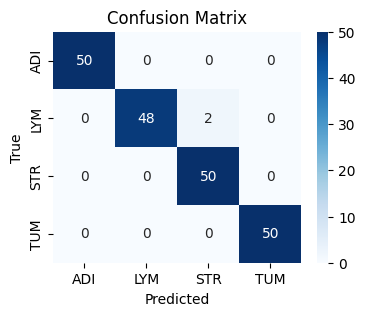

In [9]:
# Compute confusion matrix
cm = confusion_matrix(test_y_enc, pred_y)
labels = le.classes_

# Plot
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## Dimensionality reduction (Unsupervised) of feature embeddings

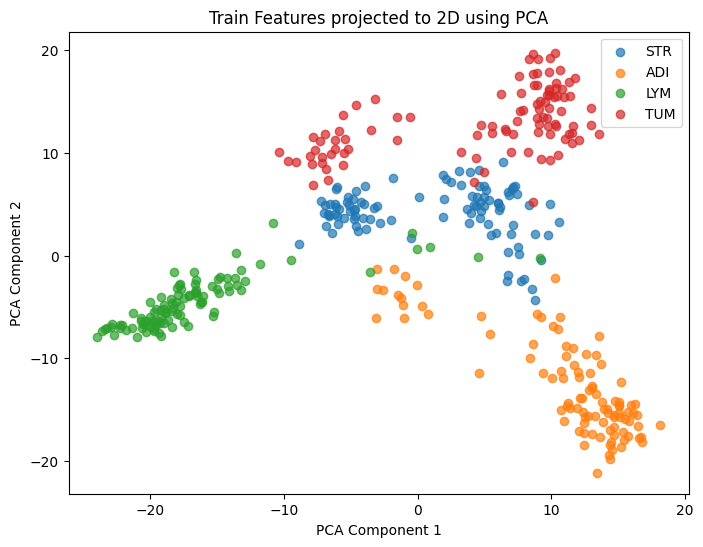

In [10]:
from sklearn.decomposition import PCA

# Reduce features to 2D
pca = PCA(n_components=2)
train_X_2d = pca.fit_transform(train_X)

# Plot
plt.figure(figsize=(8, 6))
for label in set(train_y):
    idx = train_y == label
    plt.scatter(train_X_2d[idx, 0], train_X_2d[idx, 1], label=label, alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Train Features projected to 2D using PCA")
plt.legend()
plt.show()

/home/tanweikit/Roadshow-2026-AI-Pathology/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tanweikit/Roadshow-2026-AI-Pathology/venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


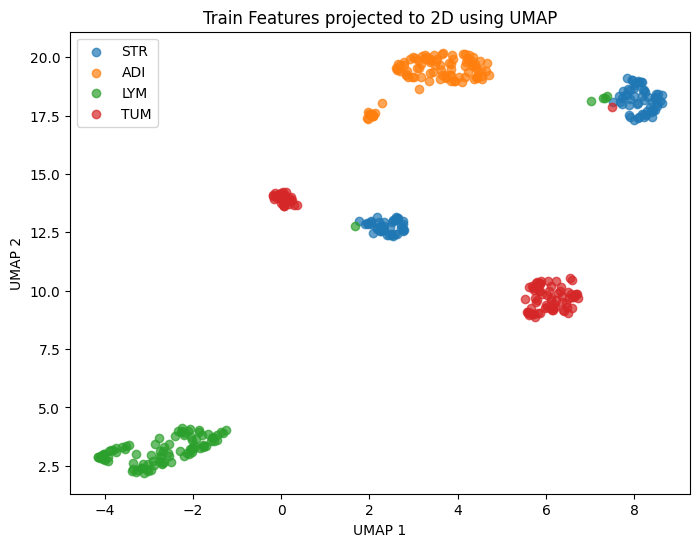

In [11]:
import umap

pca_reducer = PCA(n_components=50)
umap_reducer = umap.UMAP(n_components=2, random_state=42)

train_X_2d = umap_reducer.fit_transform(pca_reducer.fit_transform(train_X))

plt.figure(figsize=(8, 6))
for label in set(train_y):
    idx = train_y == label
    plt.scatter(train_X_2d[idx, 0], train_X_2d[idx, 1], label=label, alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Train Features projected to 2D using UMAP")
plt.legend()
plt.show()


## BONUS: Multi-modal Foundation Model
CONCH (https://huggingface.co/MahmoodLab/CONCH) is a foundation model trained with paired H&E image and text descriptions. This allows us to do zero-shot classification without any training.

In [12]:
# !pip install git+https://github.com/Mahmoodlab/CONCH.git

In [ ]:
from conch.open_clip_custom import create_model_from_pretrained, tokenize, get_tokenizer
import torch
model, preprocess = create_model_from_pretrained('conch_ViT-B-16', "hf_hub:MahmoodLab/conch")
tokenizer = get_tokenizer()

img_path = 'NCT_Images/train/STR/STR-YDKMGLDL.tif'
image = preprocess(Image.open(img_path)).unsqueeze(dim=0)       # Preprocess the image

prompts = ['Tumor tissue', 'Adipose tissue', 'Lymphocytes', 'Stroma tissue']
tokenized_prompts = tokenize(texts=prompts, tokenizer=tokenizer)    # Preprocess the texts (prompts)

with torch.inference_mode():
    image_embeddings = model.encode_image(image, proj_contrast=True, normalize=True)
    text_embeddings = model.encode_text(tokenized_prompts)

    print("Image embedding shape:")
    print(image_embeddings.shape)

    print("Text embedding shape:")
    print(text_embeddings.shape)

    sim_scores = (image_embeddings @ text_embeddings.T).squeeze(0)  # Dot product similarity

    predicted_class = prompts[sim_scores.argmax().item()]
    print("Similarity Scores:", sim_scores)
    print("Predicted Class:", predicted_class)

/home/tanweikit/Roadshow-2026-AI-Pathology/venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Image embedding shape:
torch.Size([1, 512])
Text embedding shape:
torch.Size([4, 512])
Similarity Scores: tensor([-0.1043,  0.1002,  0.0182,  0.3051])
Predicted Class: Stroma tissue
